# 🦠 COVID-19 Patient Data — Exploratory Data Analysis

---

## 📋 Table of Contents
1. [Imports & Setup](#1)
2. [EDA Report](#2)
3. [Feature Engineering](#3)
4. [Univariate Analysis](#4)
5. [Bivariate Analysis](#5)
6. [Multivariate Analysis](#6)
7. [Overall Conclusion](#7)

---
> **Dataset:** COVID-19 Patient Records | **Total Records:** ~10.5 Lakh | **Features:** 21

## 1. Imports & Setup <a id='1'></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('Covid Data.csv')

In [3]:
pd.set_option('display.max_columns',None)
df.head(2)

,USMER,MEDICAL_UNIT,SEX,PATIENT_TYPE,DATE_DIED,INTUBED,PNEUMONIA,AGE,PREGNANT,DIABETES,COPD,ASTHMA,INMSUPR,HIPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,CLASIFFICATION_FINAL,ICU
0,2,1,1,1,03-05-2020,97,1,65,2,2,2,2,2,1,2,2,2,2,2,3,97
1,2,1,2,1,03-06-2020,97,1,72,97,2,2,2,2,1,2,2,1,1,2,5,97


**📌 Note — Raw Data Preview:**  
The raw dataset is almost entirely coded in numbers (1/2/97/98/99 for yes/no/missing), which isn't human-readable yet. Columns like `INTUBED`, `PREGNANT`, and `ICU` use **97/98/99 as missing-value placeholders** rather than `NaN`, so these need to be cleaned before any real analysis can happen — this is exactly what the Feature Engineering step below takes care of.

## 2. EDA Report <a id='2'></a>

In [4]:
def eda_report(df):

    print('='*60)
    print('DATASET SHAPE')
    print(df.shape)

    print('\n'+'='*60)
    print('DUPLICATES')
    print(df.duplicated().sum())
    
    print('\n' + '='*60)
    print('DATA TYPES')
    display(df.dtypes)

    print('\n' + '='*60)
    print('UNIQUE VALUES')
    display(df.nunique())

    
    print('\n'+'='*60)
    print('MISSING VALUES')
    display(
        pd.DataFrame({
            'Null Count':df.isnull().sum(),
            'Null %':round(df.isnull().mean()*100,2)
        }).sort_values('Null %',ascending=False)
    )

    print('\n'+'='*60)
    print('NUMERICAL SUMMARY')
    display(df.describe())

    print('\n'+'='*60)
    print('CATEGORICAL SUMMARY')
    display(df.describe(include='object'))

In [5]:



  eda_report(df)

DATASET SHAPE
(1048575, 21)

DUPLICATES
812049

DATA TYPES


USMER                    int64
MEDICAL_UNIT             int64
SEX                      int64
PATIENT_TYPE             int64
DATE_DIED               object
INTUBED                  int64
PNEUMONIA                int64
AGE                      int64
PREGNANT                 int64
DIABETES                 int64
COPD                     int64
ASTHMA                   int64
INMSUPR                  int64
HIPERTENSION             int64
OTHER_DISEASE            int64
CARDIOVASCULAR           int64
OBESITY                  int64
RENAL_CHRONIC            int64
TOBACCO                  int64
CLASIFFICATION_FINAL     int64
ICU                      int64
dtype: object


UNIQUE VALUES


USMER                     2
MEDICAL_UNIT             13
SEX                       2
PATIENT_TYPE              2
DATE_DIED               401
INTUBED                   4
PNEUMONIA                 3
AGE                     121
PREGNANT                  4
DIABETES                  3
COPD                      3
ASTHMA                    3
INMSUPR                   3
HIPERTENSION              3
OTHER_DISEASE             3
CARDIOVASCULAR            3
OBESITY                   3
RENAL_CHRONIC             3
TOBACCO                   3
CLASIFFICATION_FINAL      7
ICU                       4
dtype: int64


MISSING VALUES


,Null Count,Null %
USMER,0,0.0
ASTHMA,0,0.0
CLASIFFICATION_FINAL,0,0.0
TOBACCO,0,0.0
RENAL_CHRONIC,0,0.0
OBESITY,0,0.0
CARDIOVASCULAR,0,0.0
OTHER_DISEASE,0,0.0
HIPERTENSION,0,0.0
INMSUPR,0,0.0



NUMERICAL SUMMARY


,USMER,MEDICAL_UNIT,SEX,PATIENT_TYPE,INTUBED,PNEUMONIA,AGE,PREGNANT,DIABETES,COPD,ASTHMA,INMSUPR,HIPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,CLASIFFICATION_FINAL,ICU
count,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06
mean,1.632194e+00,8.980565e+00,1.499259e+00,1.190765e+00,7.952288e+01,3.346831e+00,4.179410e+01,4.976558e+01,2.186404e+00,2.260569e+00,2.242626e+00,2.298132e+00,2.128989e+00,2.435143e+00,2.261810e+00,2.125176e+00,2.257180e+00,2.214333e+00,5.305653e+00,7.955397e+01
std,4.822084e-01,3.723278e+00,4.999997e-01,3.929041e-01,3.686889e+01,1.191288e+01,1.690739e+01,4.751073e+01,5.424242e+00,5.132258e+00,5.114089e+00,5.462843e+00,5.236397e+00,6.646676e+00,5.194850e+00,5.175445e+00,5.135354e+00,5.323097e+00,1.881165e+00,3.682307e+01
min,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
25%,1.000000e+00,4.000000e+00,1.000000e+00,1.000000e+00,9.700000e+01,2.000000e+00,3.000000e+01,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,3.000000e+00,9.700000e+01
50%,2.000000e+00,1.200000e+01,1.000000e+00,1.000000e+00,9.700000e+01,2.000000e+00,4.000000e+01,9.700000e+01,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,6.000000e+00,9.700000e+01
75%,2.000000e+00,1.200000e+01,2.000000e+00,1.000000e+00,9.700000e+01,2.000000e+00,5.300000e+01,9.700000e+01,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,7.000000e+00,9.700000e+01
max,2.000000e+00,1.300000e+01,2.000000e+00,2.000000e+00,9.900000e+01,9.900000e+01,1.210000e+02,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,7.000000e+00,9.900000e+01



CATEGORICAL SUMMARY


,DATE_DIED
count,1048575
unique,401
top,9999-99-99
freq,971633


**📌 Conclusion — Dataset Overview:**  
The dataset contains just over **1.04 million patient records across 21 columns**. A striking find here is that **812,049 rows (about 77%) are exact duplicates** — most likely repeated entries from a system that logs each hospital visit or test separately rather than one row per unique patient. This needs to be kept in mind when interpreting counts, since they likely overstate the number of *unique* people. Several columns also rely on placeholder codes (97/98/99) for missing data, which inflates the apparent 'no missing values' picture until those codes are properly converted to `NaN`.

## 3. Feature Engineering <a id='3'></a>

In [6]:
# Death column 
df['Death'] = np.where(df['DATE_DIED'] == '9999-99-99', 0, 1)

# Sex encoding
df['SEX'] = df['SEX'].replace({1: 'Female', 2: 'Male'})

# Age Groups
bins   = [0, 2, 12, 19, 30, 60, 121]
labels = ['Infants', 'Children', 'Teens', 'Young Adults', 'Adults', 'Seniors']
df['Age_Group'] = pd.cut(df['AGE'], bins=bins, labels=labels, include_lowest=True)

# COVID Positive
df['COVID_Positive'] = np.where(df['CLASIFFICATION_FINAL'] <= 3, 1, 0)

# Hospitalized
df['Hospitalized'] = df['PATIENT_TYPE'].replace({1: 0, 2: 1})

# Replace encoded unknowns with NaN 
replacements = {
    'INTUBED':       {97: np.nan, 99: np.nan},
    'PNEUMONIA':     {99: np.nan},
    'PREGNANT':      {97: np.nan, 98: np.nan},
    'DIABETES':      {98: np.nan},
    'COPD':          {98: np.nan},
    'ASTHMA':        {98: np.nan},
    'INMSUPR':       {98: np.nan},
    'HIPERTENSION':  {98: np.nan},
    'CARDIOVASCULAR':{98: np.nan},
    'OBESITY':       {98: np.nan},
    'RENAL_CHRONIC': {98: np.nan},
    'TOBACCO':       {98: np.nan},
    'ICU':           {97: np.nan, 99: np.nan},
    'OTHER_DISEASE': {98: np.nan}
}
df.replace(replacements, inplace=True)

# Convert 1/2 binary → 1/0
binary_cols = ['INTUBED','PNEUMONIA','DIABETES','COPD','ASTHMA','INMSUPR',
               'HIPERTENSION','OTHER_DISEASE','CARDIOVASCULAR','OBESITY',
               'RENAL_CHRONIC','TOBACCO','ICU','PREGNANT']
for col in binary_cols:
    df[col] = df[col].replace({1: 1, 2: 0})

# Date & Month
df['DATE_DIED'] = pd.to_datetime(df['DATE_DIED'], errors='coerce')
df['Death_Year'] = df['DATE_DIED'].dt.year
df['Death_Month_2020'] = np.where(df['Death_Year'] == 2020, df['DATE_DIED'].dt.month_name(), np.nan)
df['Death_Month_2021'] = np.where(df['Death_Year'] == 2021, df['DATE_DIED'].dt.month_name(), np.nan)

# Severity
df['severity'] = np.where((df['ICU'] == 1) | (df['INTUBED'] == 1), 'Critical', 'Normal')

#TOTAL DISEASES
disease_mapping = {
    'PNEUMONIA': 1,'DIABETES': 1,'COPD': 1,'ASTHMA': 1,'INMSUPR': 1,'HIPERTENSION': 1,'CARDIOVASCULAR': 1,'OBESITY': 1,
    'RENAL_CHRONIC': 1,'OTHER_DISEASE': 1
}

df['TOTAL_DISEASES'] = 0

for col, positive_value in disease_mapping.items():
    df['TOTAL_DISEASES'] += (df[col] == positive_value).astype(int)
    

print('✅ Feature Engineering complete!')
print(f"Deaths: {df['Death'].sum():,}  |  COVID Positive: {df['COVID_Positive'].sum():,}  |  Hospitalized: {df['Hospitalized'].sum():,}")
df.head(2)

✅ Feature Engineering complete!
Deaths: 76,942  |  COVID Positive: 391,979  |  Hospitalized: 200,031


,USMER,MEDICAL_UNIT,SEX,PATIENT_TYPE,DATE_DIED,INTUBED,PNEUMONIA,AGE,PREGNANT,DIABETES,COPD,ASTHMA,INMSUPR,HIPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,CLASIFFICATION_FINAL,ICU,Death,Age_Group,COVID_Positive,Hospitalized,Death_Year,Death_Month_2020,Death_Month_2021,severity,TOTAL_DISEASES
0,2,1,Female,1,2020-03-05,NaN,1.0,65,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,3,NaN,1,Seniors,1,0,2020.0,March,NaN,Normal,2
1,2,1,Male,1,2020-03-06,NaN,1.0,72,NaN,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,5,NaN,1,Seniors,0,0,2020.0,March,NaN,Normal,4


Several new features are derived from raw columns to make the data more analysis-friendly:
- **Death** — binary flag (1 = died, 0 = survived) derived from `DATE_DIED`
- **SEX** — mapped from numeric codes to `'Female'` / `'Male'`
- **Age_Group** — patients binned into: *Infants, Children, Teens, Young Adults, Adults, Seniors*
- **COVID_Positive** — 1 if `CLASIFFICATION_FINAL ≤ 3`, else 0
- **Hospitalized** — 1 if admitted, 0 if outpatient
- **severity** — `'Critical'` (ICU or intubated), `'Normal'` otherwise
- **Death_Month_2020 / 2021** — month of death split by year for temporal analysis
- **Total_Diseases** -- Num of deaceases per person count

**📌 Conclusion — Feature Engineering Output:**  
After engineering the core features, the dataset shows **76,942 deaths**, **391,979 confirmed COVID-positive cases**, and **200,031 hospitalizations** out of ~1.05 million records. These three new flags (`Death`, `COVID_Positive`, `Hospitalized`) turn messy raw codes into clean, analysis-ready binary columns, and they become the backbone of almost every plot in the rest of this notebook.

## 4. Univariate Analysis <a id='4'></a>

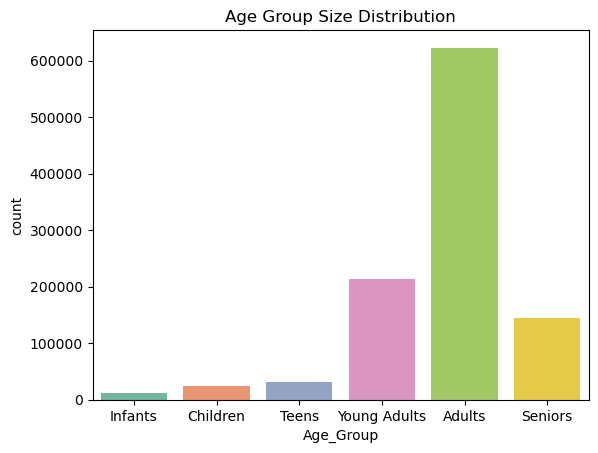

In [8]:
sns.countplot(x='Age_Group',data=df,palette='Set2')

plt.title('Age Group Size Distribution')
plt.show()

**📌 Conclusion — Age Group Distribution:**  
The dataset is dominated by **Adults (30–60)** and **Seniors (60+)**, which reflects the real-world pattern of COVID-19 affecting working-age and elderly populations most heavily. Infants and teenagers represent only a small fraction of cases.


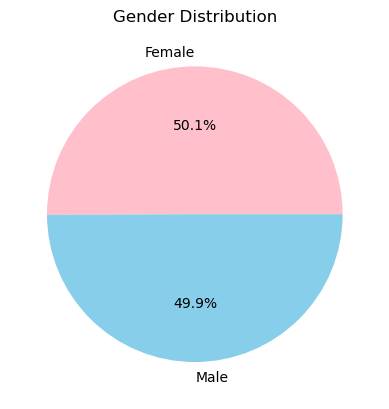

In [9]:
df['SEX'].value_counts().plot.pie(autopct='%1.1f%%',ylabel='',colors=['pink', 'skyblue'])

plt.title('Gender Distribution')
plt.show()

**📌 Conclusion — Gender Distribution:**  
The dataset is roughly split between males and females, with a slight male majority. This is consistent with global observations that males were more likely to seek hospital care or test positive for COVID-19.

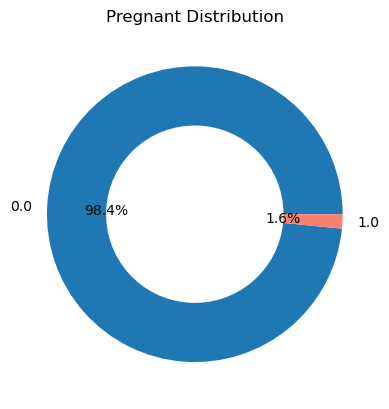

In [10]:
df['PREGNANT'].value_counts().plot.pie(autopct='%1.1f%%',ylabel='',colors=['#1f77b4', 'salmon'],wedgeprops={'width':0.4})

plt.title('Pregnant Distribution')
plt.show()

**📌 Conclusion — Pregnancy Distribution:**  
The vast majority of female patients were non-pregnant. Pregnant patients form a small but important subgroup that warrants special attention in healthcare planning due to elevated risk during COVID-19.

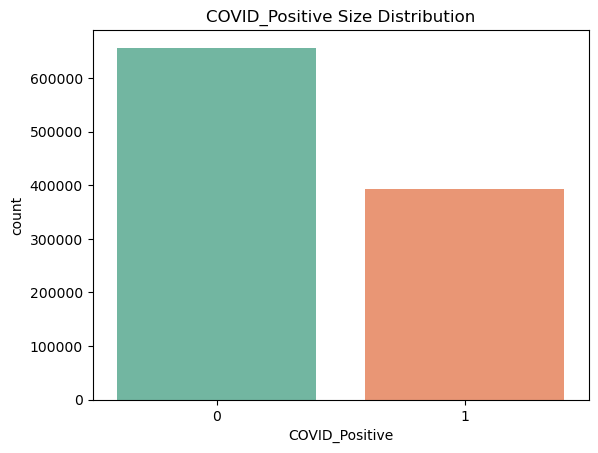

In [11]:
sns.countplot(x='COVID_Positive',data=df,palette='Set2')

plt.title('COVID_Positive Size Distribution')
plt.show()

**📌 Conclusion — COVID Positive Distribution:**  
A large proportion of patients in this dataset tested positive for COVID-19 (classification ≤ 3), indicating that the dataset is heavily skewed toward confirmed cases — which is expected given it originates from healthcare facilities.

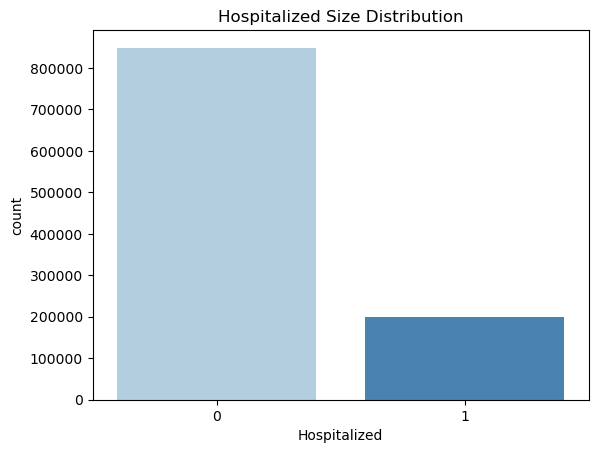

In [12]:
sns.countplot(x='Hospitalized',data=df,palette='Blues')

plt.title('Hospitalized Size Distribution')
plt.show()

**📌 Conclusion — Hospitalization Distribution:**  
The majority of patients were outpatients (not hospitalised). This shows that while many people tested positive, only a subset required inpatient care — an important distinction for resource allocation.

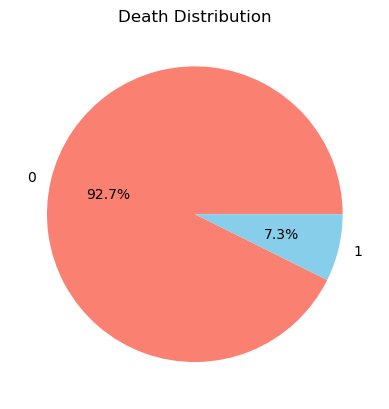

In [13]:
df['Death'].value_counts().plot.pie(autopct='%1.1f%%',ylabel='',colors=['salmon','skyblue'])

plt.title('Death Distribution')
plt.show()

**📌 Conclusion — Death Distribution:**  
A meaningful fraction of patients in this dataset died from COVID-19 or its complications. The relatively high death rate compared to general population estimates reflects that this dataset comes from hospital records, where severity is inherently higher.


## 5. Bivariate Analysis <a id='5'></a>

#### Gender vs Death

In [14]:
pd.crosstab(df['SEX'], df['Death'])

Death,0,1
SEX,,
Female,497662,27402
Male,473971,49540


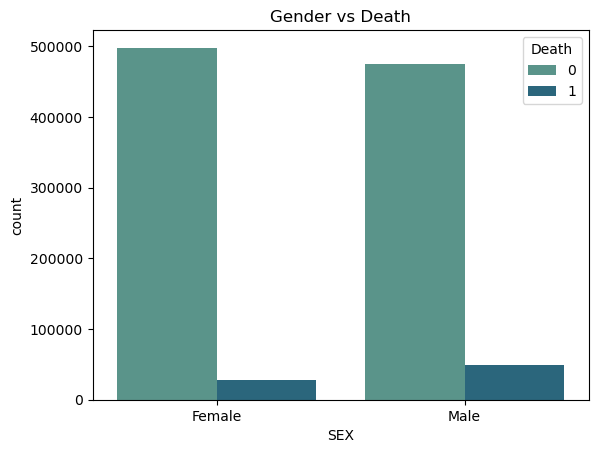

In [15]:
sns.countplot(x='SEX',hue='Death',data=df,palette='crest')

plt.title('Gender vs Death')
plt.show()

**📌 Conclusion — Gender vs Death:**  
Males show a noticeably higher death count than females despite a relatively balanced gender distribution in the dataset. This aligns with global findings that biological and behavioural factors make males more vulnerable to severe COVID-19 outcomes.


#### Age Group vs Death

In [16]:
pd.crosstab(df['Age_Group'], df['Death'])

Death,0,1
Age_Group,,
Infants,11393,449
Children,24413,218
Teens,30996,207
Young Adults,211932,1579
Adults,590100,32916
Seniors,102799,41573


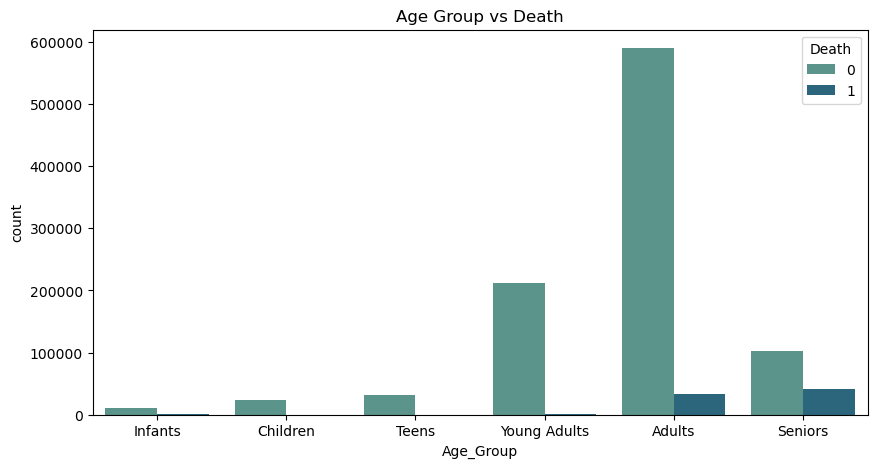

In [17]:
plt.figure(figsize=(10,5))

sns.countplot(x='Age_Group',hue='Death',data=df,palette='crest')

plt.title('Age Group vs Death')
plt.show()

**📌 Conclusion — Age Group vs Death:**  
**Seniors (60+)** suffer by far the highest mortality rate, followed by Adults. Children and teenagers have extremely low death counts. This strongly confirms age as the single most powerful predictor of COVID-19 fatality.

#### Pregnant vs Death

In [18]:
ct=pd.crosstab(df['PREGNANT'], df['Death'])
ct

Death,0,1
PREGNANT,,
0.0,485933,27246
1.0,8042,89


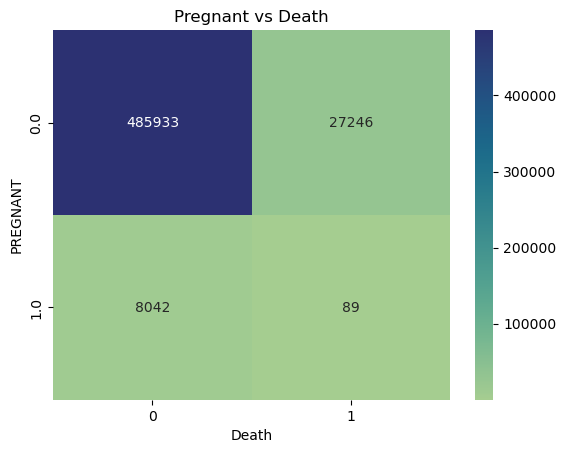

In [19]:
sns.heatmap(ct, annot=True, fmt='d', cmap='crest')
plt.title("Pregnant vs Death")
plt.show()

**📌 Conclusion — Pregnancy vs Death:**  
Most pregnant patients survived. However, the heatmap reveals that a subset of pregnant patients did die, underscoring the need for prioritised medical care for pregnant COVID-19 patients.

#### Covid_Positive vs Death

In [20]:
pd.crosstab(df['Death'], df['COVID_Positive'], normalize='index')*100

COVID_Positive,0,1
Death,,
0,65.239653,34.760347
1,29.510540,70.489460


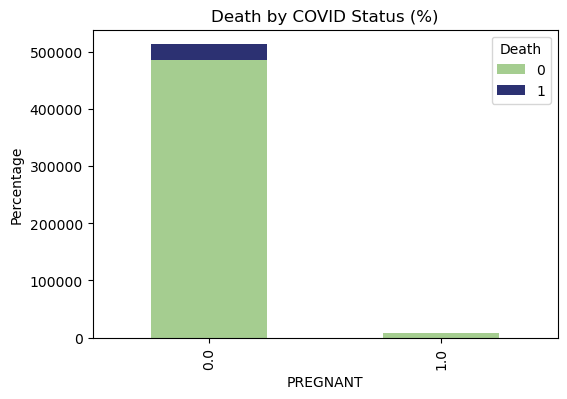

In [21]:
ct.plot(kind='bar',stacked=True,figsize=(6,4),colormap='crest')

plt.title('Death by COVID Status (%)')
plt.ylabel('Percentage')
plt.show()

**📌 Conclusion — COVID Status vs Death:**  
COVID-positive patients have a substantially higher death proportion compared to those who tested negative. This confirms that confirmed infection is a major mortality driver, not just a coincidental finding.

#### Age Group vs Death

Death              0      1
Age_Group                  
Infants        11393    449
Children       24413    218
Teens          30996    207
Young Adults  211932   1579
Adults        590100  32916
Seniors       102799  41573


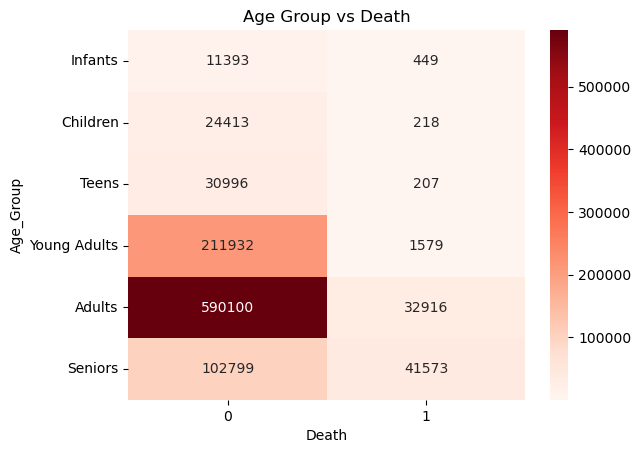

In [22]:
ct = pd.crosstab(df['Age_Group'], df['Death'])
print(ct)
sns.heatmap(ct, annot=True, fmt='d', cmap='Reds')
plt.title('Age Group vs Death')
plt.show()

**📌 Conclusion — Age Group vs Death (Heatmap):**  
The heatmap reinforces the countplot finding — absolute death counts are concentrated among **Adults and Seniors**. The colour gradient makes it immediately clear that senior mortality dwarfs all other age groups.

#### Hospitalized vs Death

Death                 0          1
Hospitalized                      
0             99.189671   0.810329
1             64.972429  35.027571


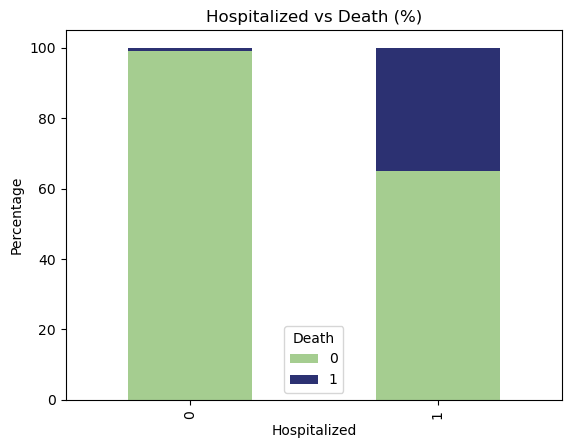

In [23]:
ct = pd.crosstab(df['Hospitalized'],df['Death'],normalize='index') * 100
print(ct)
ct.plot(kind='bar', stacked=True ,colormap='crest')
plt.title('Hospitalized vs Death (%)')
plt.ylabel('Percentage')
plt.show()

**📌 Conclusion — Hospitalization vs Death:**  
Hospitalised patients have a disproportionately higher death rate compared to outpatients. This is expected — hospitalisation itself signals disease severity — and reinforces the need for aggressive in-hospital care for admitted COVID patients.


#### Comorbidities vs Death

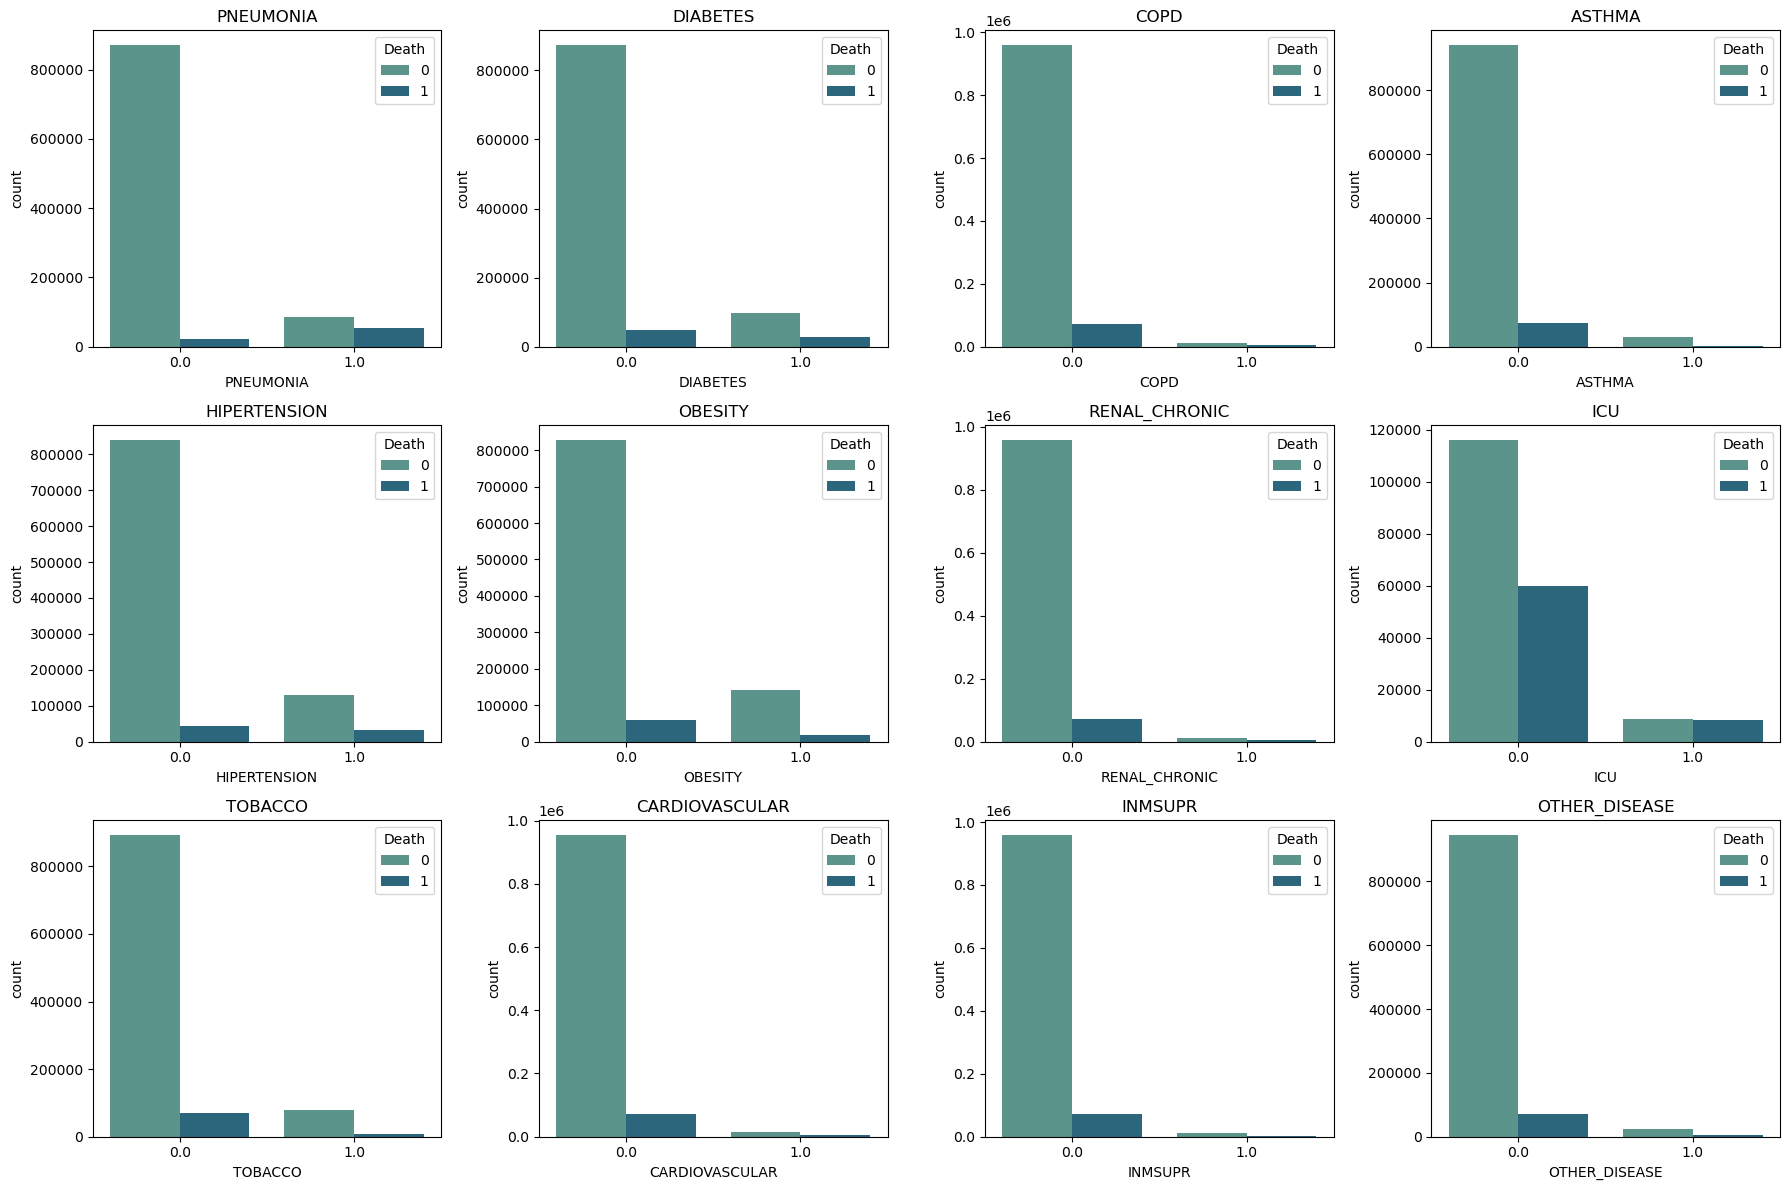

In [24]:
cols = ['PNEUMONIA','DIABETES','COPD','ASTHMA','HIPERTENSION','OBESITY','RENAL_CHRONIC','ICU','TOBACCO','CARDIOVASCULAR','INMSUPR','OTHER_DISEASE']
plt.figure(figsize=(18,12))
for i, col in enumerate(cols, 1):
    plt.subplot(3, 4, i)
    sns.countplot(x=col, hue='Death', data=df,palette='crest')
    plt.title(col)

plt.tight_layout()
plt.show()

**📌 Conclusion — Comorbidities vs Death:**  
Patients with **Pneumonia, Diabetes, Hypertension, Obesity, Renal Chronic disease, and Cardiovascular disease** show markedly elevated death counts. **Pneumonia** stands out as the most lethal comorbidity, while **COPD, Asthma, and Tobacco use** show moderate effects. Patients with **ICU admission** also have a very high fatality rate, confirming that critical-care patients face the worst outcomes.

#### Severity vs Death

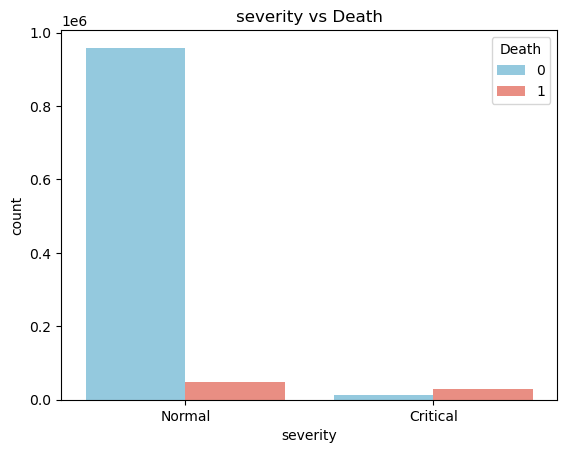

In [25]:
sns.countplot(x='severity',hue='Death',data=df,palette=['skyblue', 'salmon'])

plt.title('severity vs Death')
plt.show()

**📌 Conclusion — Disease Severity vs Death:**  
**Critical patients** (those who required ICU admission or intubation) have a dramatically higher death rate than Normal patients. This validates the severity classification as a strong proxy for mortality risk and highlights the importance of early intervention before a patient reaches critical status.

#### Total diseases vs Covid positive

COVID_Positive       0       1
TOTAL_DISEASES                
0               424929  195696
1               142356  103007
2                55354   54017
3                22793   26706
4                 8004    9492
5                 2242    2368
6                  646     512
7                  157     103
8                   45      25
9                   63      42
10                   7      11


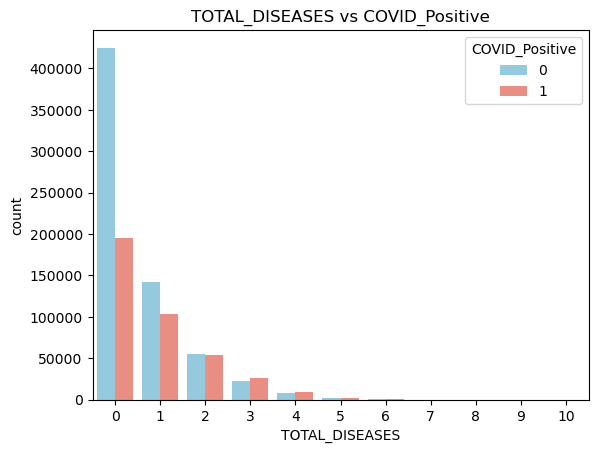

In [26]:
ct = pd.crosstab(df['TOTAL_DISEASES'], df['COVID_Positive'])
print(ct)
sns.countplot(x='TOTAL_DISEASES',hue='COVID_Positive',data=df,palette=['skyblue', 'salmon'])

plt.title('TOTAL_DISEASES vs COVID_Positive')
plt.show()

#### Total diseases vs Death

Death                0      1
TOTAL_DISEASES               
0               613102   7523
1               222794  22569
2                87521  21850
3                34108  15391
4                10551   6945
5                 2587   2023
6                  645    513
7                  157    103
8                   55     15
9                   99      6
10                  14      4


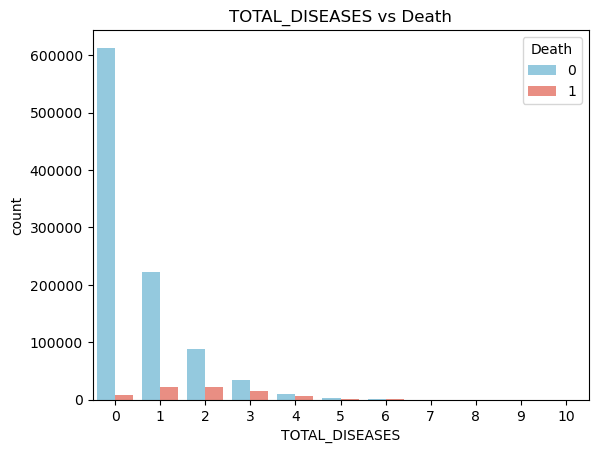

In [27]:
ct = pd.crosstab(df['TOTAL_DISEASES'], df['Death'])
print(ct)
sns.countplot(x='TOTAL_DISEASES',hue='Death',data=df,palette=['skyblue', 'salmon'])

plt.title('TOTAL_DISEASES vs Death')
plt.show()

**📌 Conclusion — Total Diseases vs Death:**  
Death counts climb sharply with comorbidity load: patients with zero diseases had a death rate of about 1.2% (7,523 of 620,625), but that climbs to roughly 31% for patients with 3 diseases (15,391 of 49,499) and even higher for those with more. This is one of the cleanest dose-response relationships in the whole dataset — **the more pre-existing conditions a patient has, the higher their chance of dying from COVID-19.**

#### Total Diseases vs Age Group

Age_Group       Infants  Children  Teens  Young Adults  Adults  Seniors
TOTAL_DISEASES                                                         
0                  8342     20083  26016        169086  362265    34833
1                  2779      3596   4192         36129  158728    39939
2                   561       768    742          6503   66242    34555
3                   134       149    197          1373   25528    22118
4                    22        26     39           310    7886     9213
5                     1         3     11            62    1738     2795
6                     1         1      2            12     439      703
7                     1         0      0             5      80      174
8                     0         1      0             9      29       31
9                     0         4      3            20      70        8
10                    1         0      1             2      11        3


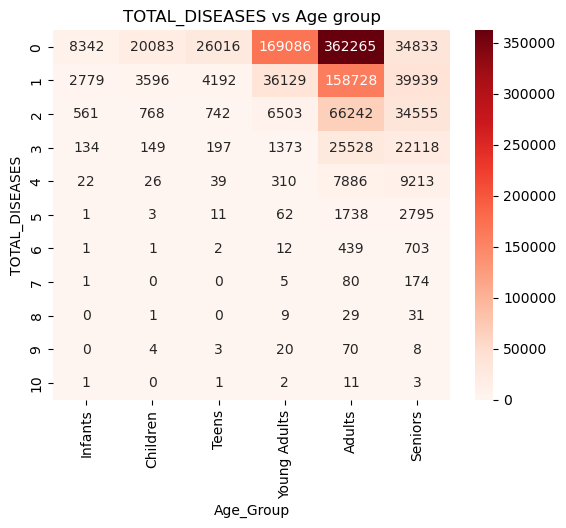

In [28]:
ct = pd.crosstab(df['TOTAL_DISEASES'], df['Age_Group'])
print(ct)
sns.heatmap(ct, annot=True, fmt='d', cmap='Reds')
plt.title('TOTAL_DISEASES vs Age group')
plt.show()

**📌 Conclusion — Total Diseases vs Age Group:**  
**Seniors and Adults carry by far the highest comorbidity burden** — at 2+ diseases, Seniors and Adults dominate the counts (e.g. 34,555 Seniors vs only 6,503 Young Adults at 2 diseases). Younger groups (Infants, Children, Teens) are concentrated almost entirely at 0–1 diseases. This confirms that **age and comorbidity accumulation move together**, compounding risk for older patients.

## 6. Multivariate Analysis <a id='6'></a>

#### Monthly Deaths (2020 vs 2021)

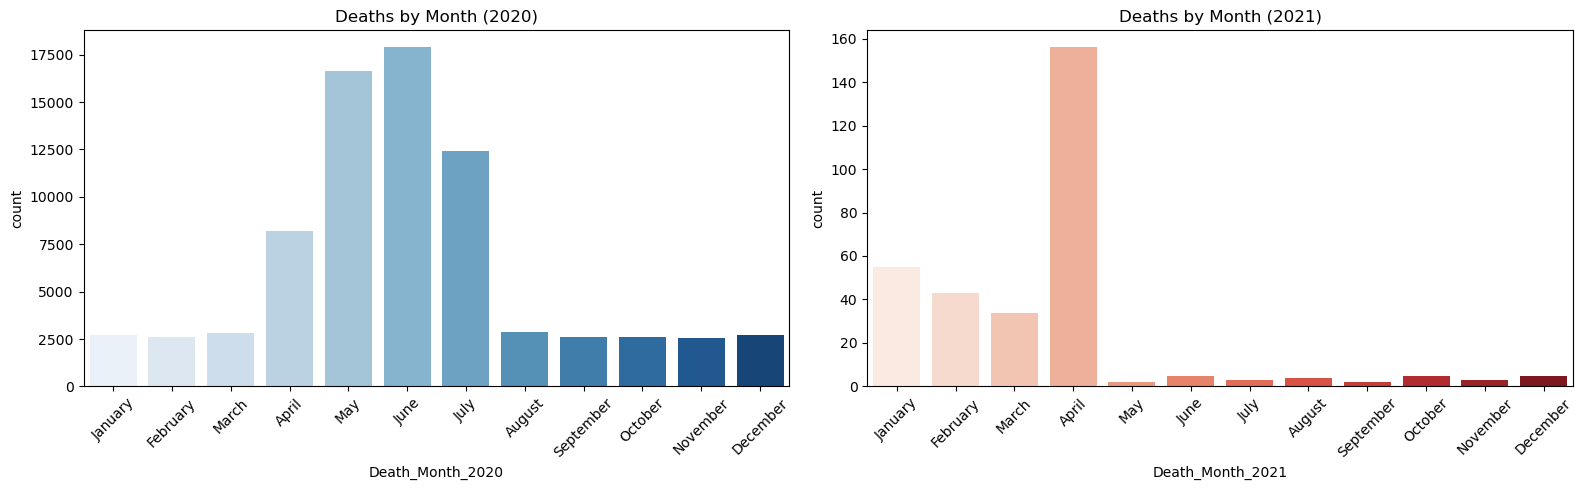

In [29]:
month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']

fig, ax = plt.subplots(1, 2, figsize=(16,5))

sns.countplot(x='Death_Month_2020',data=df,order=month_order,palette='Blues',ax=ax[0])

ax[0].set_title('Deaths by Month (2020)')
ax[0].tick_params(axis='x', rotation=45)

sns.countplot(x='Death_Month_2021',data=df,order=month_order,palette='Reds',ax=ax[1])

ax[1].set_title('Deaths by Month (2021)')
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout()

plt.show()

**📌 Conclusion — Monthly Deaths (2020 vs 2021):**  
In **2020**, COVID deaths peaked during **July–August** (first major wave in Mexico) and remained elevated through the year. In **2021**, deaths surged sharply in **January–February** (the deadly second wave), then declined as vaccination campaigns accelerated. This temporal pattern highlights the critical window when healthcare systems faced maximum pressure.

#### Deaths by Age Group and Gender

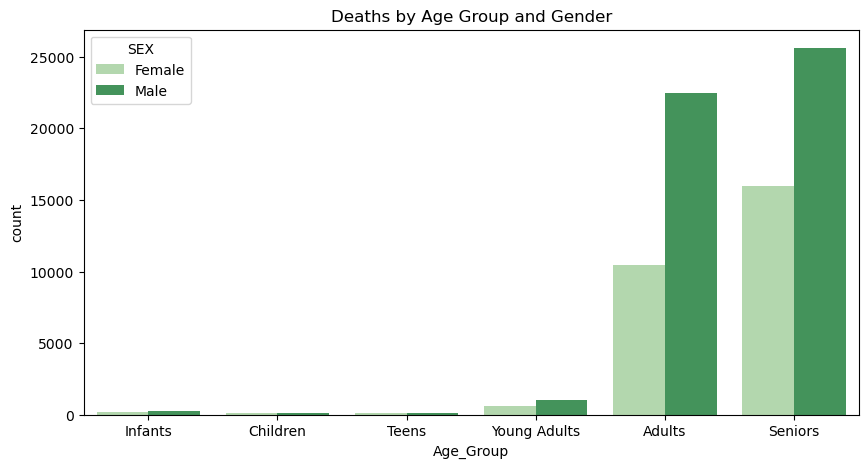

In [30]:
plt.figure(figsize=(10,5))

sns.countplot(x='Age_Group',hue='SEX',palette='Greens',data=df[df['Death']==1])

plt.title('Deaths by Age Group and Gender')
plt.show()

**📌 Conclusion — Deaths by Age Group and Gender:**  
Among fatalities, **male Seniors** account for the highest death count, followed by **female Seniors**. Across all age groups, males consistently show higher death counts than females. This confirms the compounded risk of being male and elderly in COVID-19 outcomes.

#### COVID Status, Gender & Death

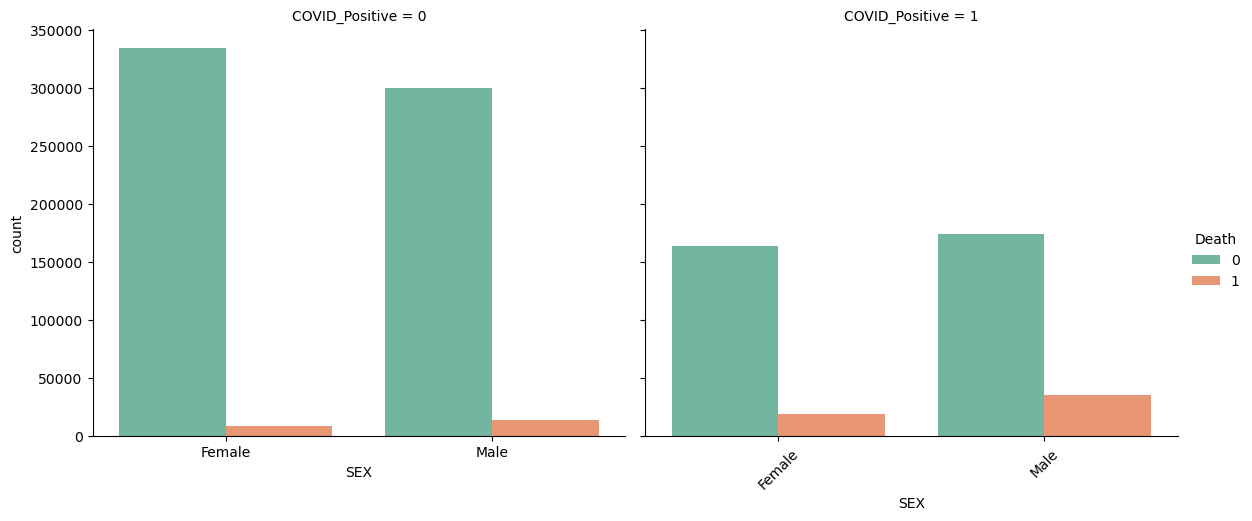

In [31]:
sns.catplot(x='SEX',hue='Death',col='COVID_Positive',palette='Set2',data=df,kind='count',height=5,aspect=1.2)

plt.xticks(rotation=45)
plt.show()

**📌 Conclusion — COVID Status, Gender & Death:**  
COVID-positive males show the highest combined death burden. Even among COVID-positive females, deaths are elevated compared to COVID-negative patients. This three-way interaction confirms that **male sex + COVID positivity** is the highest-risk combination in this dataset.

#### severitys, Gender & Death

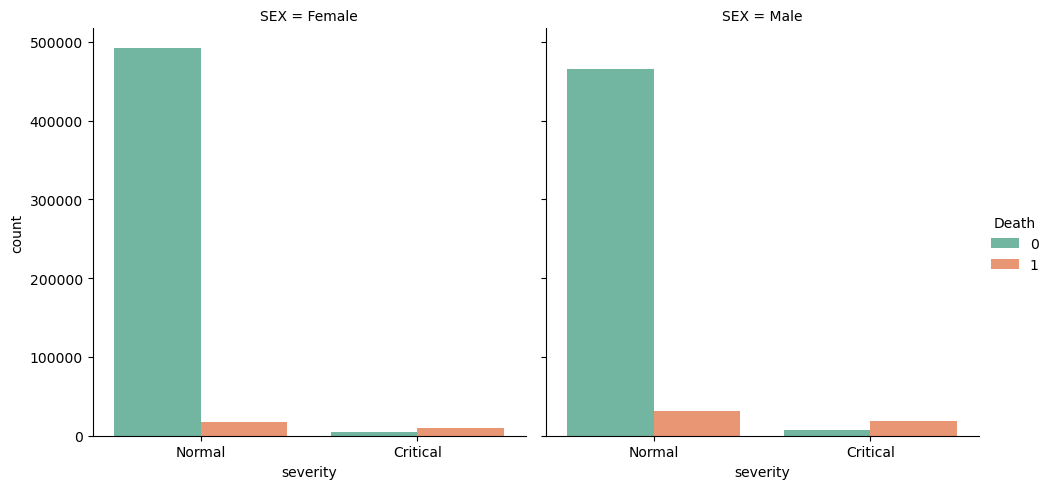

In [32]:
sns.catplot(data=df,x='severity',hue='Death',col='SEX',kind='count',palette='Set2')
plt.show()

#### Age Group × COVID Status × Death

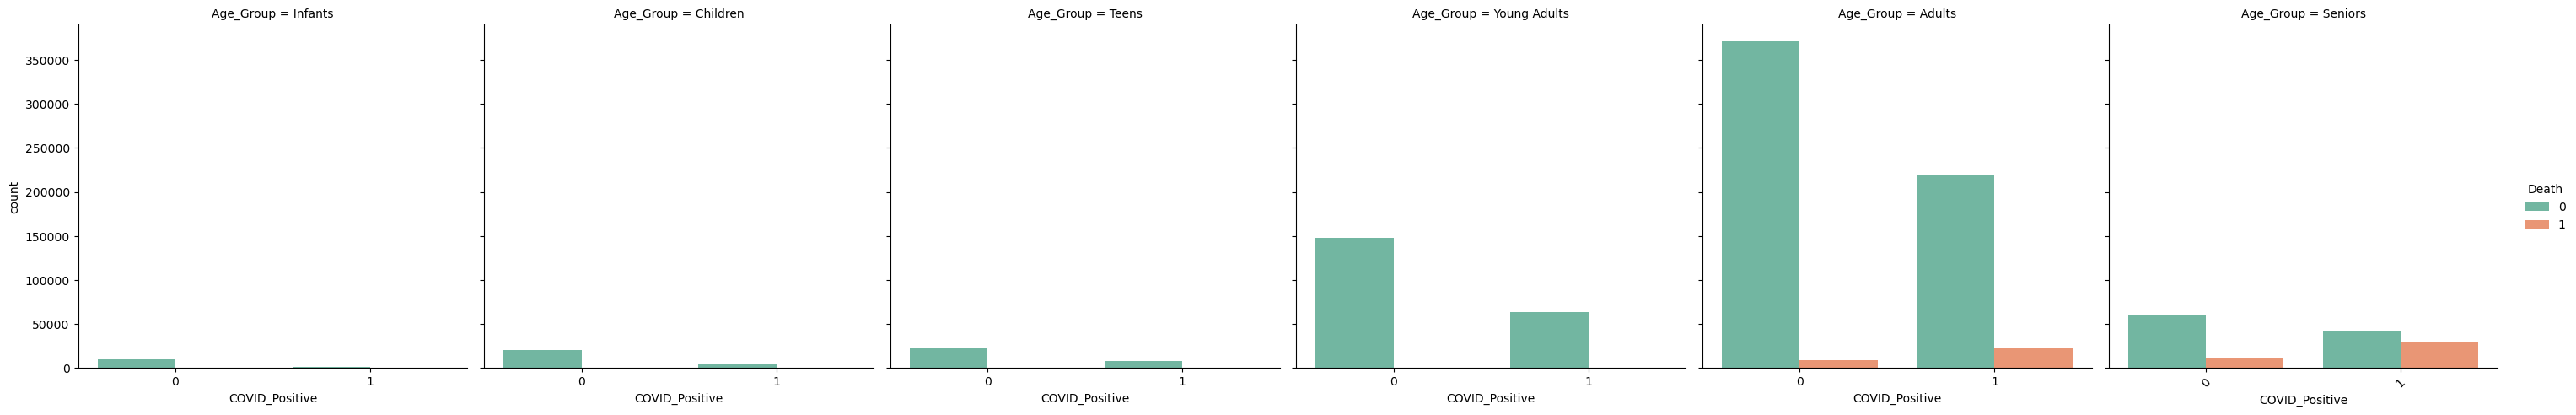

In [33]:
sns.catplot(x='COVID_Positive',hue='Death',col='Age_Group',kind='count',data=df,palette='Set2')
plt.xticks(rotation=45)
plt.show()

**📌 Conclusion — Age Group × COVID Status × Death:**  
Among COVID-positive patients, **Adults and Seniors** dominate the death counts. Interestingly, even among COVID-negative patients (possible non-COVID hospitalisations), senior deaths are still present — highlighting how vulnerable the elderly are regardless of COVID status.

#### ICU × Gender × Death

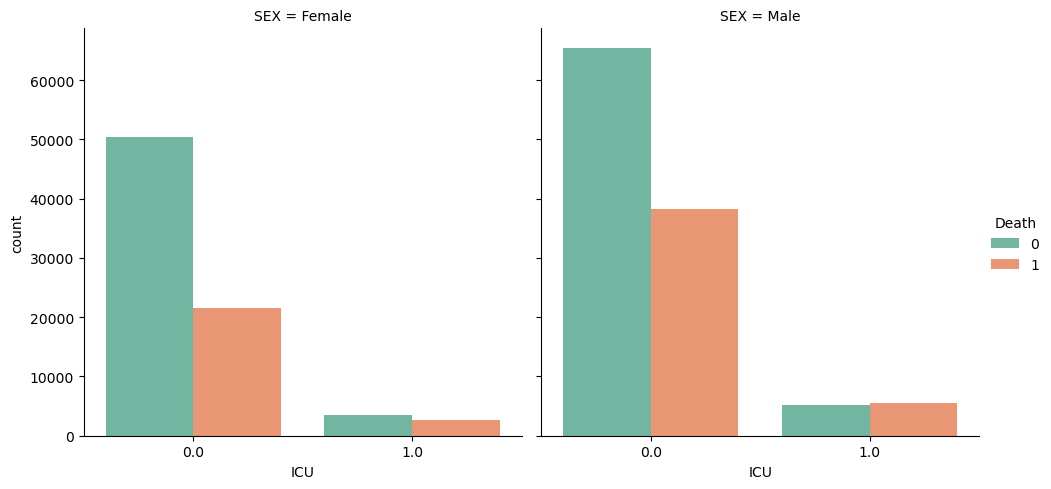

In [34]:
sns.catplot(data=df,x='ICU',hue='Death',col='SEX',kind='count',palette='Set2')
plt.show()

**📌 Conclusion — ICU, Gender & Death:**  
ICU admission is a major red flag for both sexes — death counts jump sharply once a patient enters ICU, even though far fewer patients are admitted there overall. Males again show a higher death toll than females both in and out of the ICU, but the gap narrows somewhat among ICU patients, suggesting that once a case becomes severe enough for ICU care, the disease itself becomes the dominant risk factor over gender.

#### Hospitalized × Gender × Death

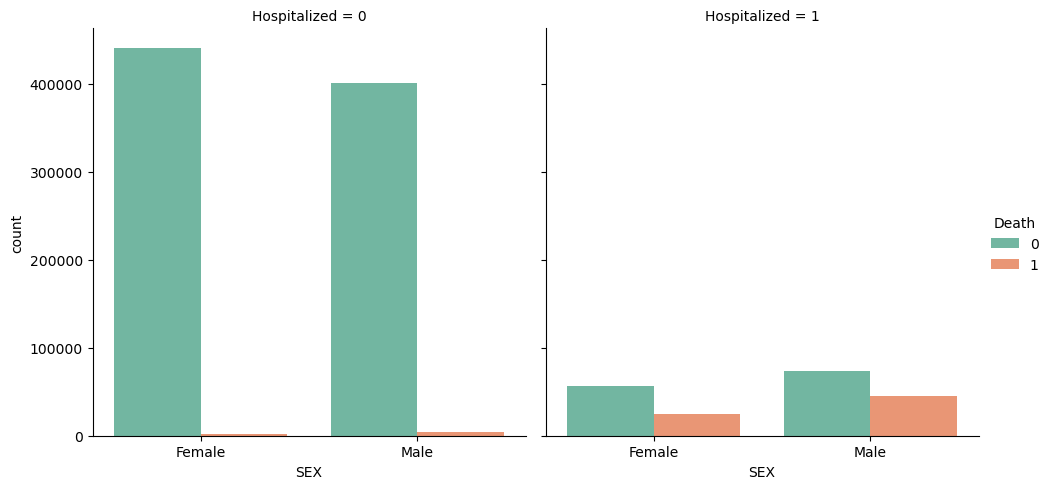

In [35]:
sns.catplot(data=df,x='SEX',hue='Death',col='Hospitalized',kind='count',palette='Set2')
plt.show()

**📌 Conclusion — Hospitalization, Gender & Death:**  
Hospitalized patients show much higher death counts than outpatients for both men and women, confirming the earlier hospitalization-vs-death finding holds regardless of sex. Within the hospitalized group, men still show a higher death count than women, reinforcing that gender adds an additional layer of risk even after accounting for how sick a patient already is.

#### TOTAL DISEASES × Gender × Death

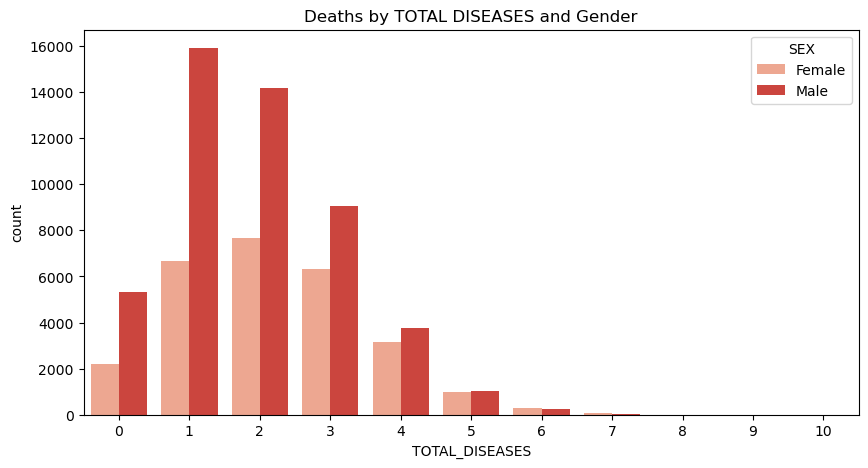

In [36]:
plt.figure(figsize=(10,5))

sns.countplot(x='TOTAL_DISEASES',hue='SEX',palette='Reds',data=df[df['Death']==1])

plt.title('Deaths by TOTAL DISEASES and Gender')
plt.show()

**📌 Conclusion — Total Diseases × Gender (Among Deaths):**  
Among patients who died, the largest share had only **1–2 comorbidities**, not the maximum count — likely because few patients overall reach high comorbidity counts (a volume effect, not a risk-reduction effect, per the earlier death-rate-by-disease-count finding). At every comorbidity level, **male deaths outnumber female deaths**, most visibly at 1 disease (~16,000 male vs ~6,700 female), reaffirming the consistent male mortality disadvantage seen throughout this analysis.

#### TOTAL DISEASES × Covid  × Death

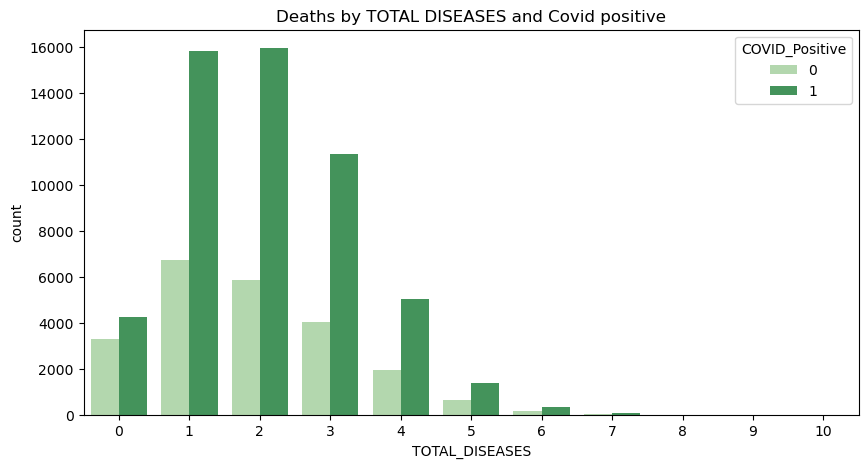

In [37]:
plt.figure(figsize=(10,5))

sns.countplot(x='TOTAL_DISEASES',hue='COVID_Positive',palette='Greens',data=df[df['Death']==1])

plt.title('Deaths by TOTAL DISEASES and Covid positive')
plt.show()

**📌 Conclusion — Total Diseases × COVID Status (Among Deaths):**  
Deaths with comorbidities are **predominantly COVID-positive** across nearly every disease-count bucket — at 1 and 2 diseases, COVID-positive deaths (~15,800 and ~16,000) far exceed COVID-negative deaths (6,700 and ~5,900). This indicates that confirmed COVID infection, combined with comorbidities, is the dominant pathway to death in this dataset, rather than comorbidities alone.

#### TOTAL DISEASES & Death

In [38]:
disease_cols = ['PNEUMONIA','DIABETES','COPD','ASTHMA','HIPERTENSION','OBESITY','RENAL_CHRONIC',
                'CARDIOVASCULAR','INMSUPR','TOBACCO','OTHER_DISEASE']

# disease and died
one_disease_death = df[(df['TOTAL_DISEASES'] == 1) &(df['Death'] == 1)]

one_disease_death[disease_cols].sum().sort_values(ascending=False)

PNEUMONIA         15998.0
HIPERTENSION       2170.0
DIABETES           1764.0
TOBACCO            1568.0
OBESITY            1349.0
OTHER_DISEASE       480.0
COPD                235.0
RENAL_CHRONIC       171.0
INMSUPR             171.0
CARDIOVASCULAR      134.0
ASTHMA               97.0
dtype: float64

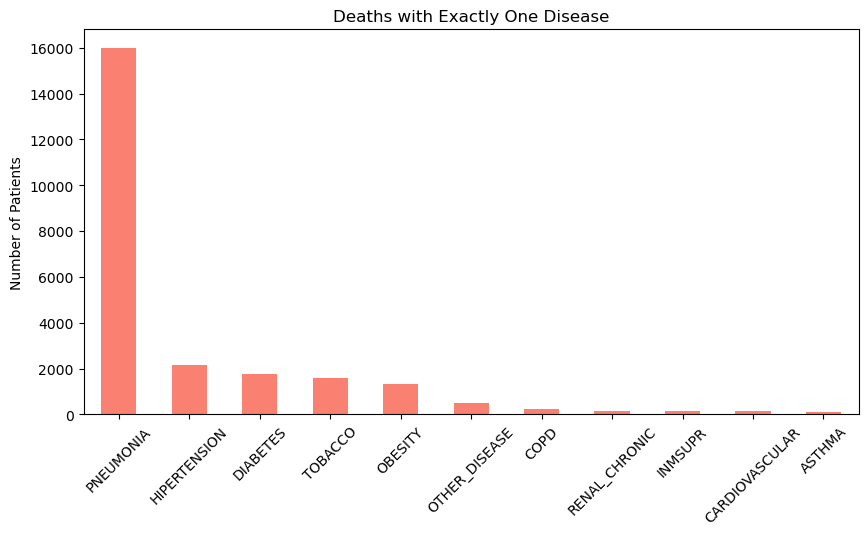

In [39]:
one_disease_death[disease_cols].sum()\
    .sort_values(ascending=False)\
    .plot(kind='bar', figsize=(10,5), color='salmon')

plt.title('Deaths with Exactly One Disease')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45)
plt.show()

**📌 Conclusion — Deaths with Exactly One Disease:**  
Among patients who died with **only a single comorbidity**, **Pneumonia is overwhelmingly the most common** (16,000 deaths) — nearly 7× higher than the next-highest condition, Hypertension (~2,200). This singles out Pneumonia as the most lethal standalone comorbidity, far ahead of Diabetes, Tobacco use, and Obesity, and suggests it is often the direct cause of respiratory failure rather than a background risk factor.

#### Death Rate (%) by Age Group & Disease

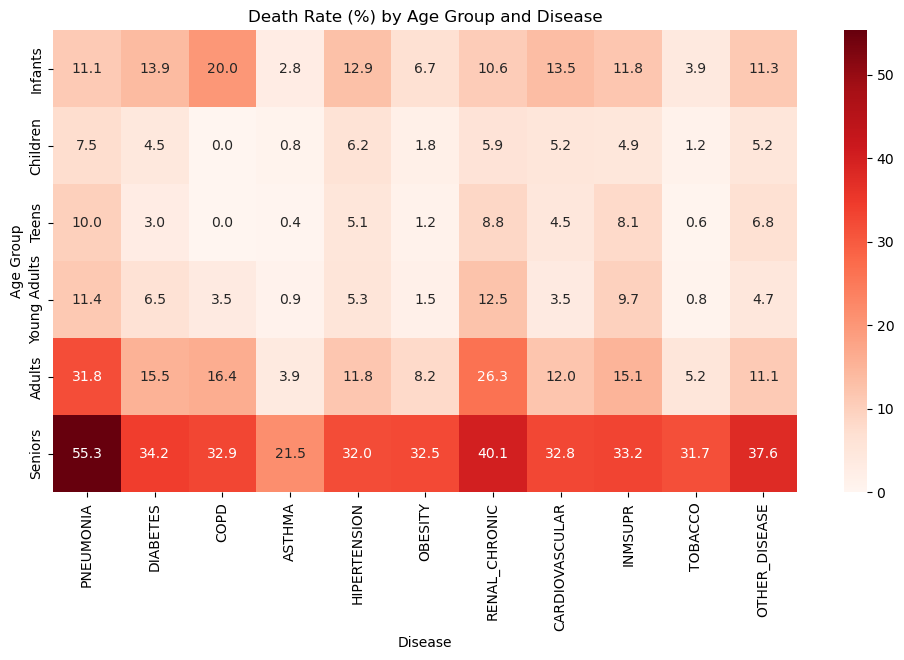

In [41]:
cols = ['PNEUMONIA','DIABETES','COPD','ASTHMA','HIPERTENSION','OBESITY','RENAL_CHRONIC','CARDIOVASCULAR','INMSUPR','TOBACCO','OTHER_DISEASE']
death_heatmap = pd.DataFrame()
for col in cols:death_heatmap[col] = (df[df[col] == 1].groupby('Age_Group')['Death'].mean() * 100)
plt.figure(figsize=(12,6))
sns.heatmap(death_heatmap,annot=True,fmt='.1f',cmap='Reds')
plt.title('Death Rate (%) by Age Group and Disease')
plt.ylabel('Age Group')
plt.xlabel('Disease')
plt.show()

**📌 Conclusion — Death Rate (%) by Age Group & Disease:**  
This heatmap confirms two compounding effects: **age** and **disease type**. Death rates rise sharply with age for every disease — Seniors hit **55.3% mortality with Pneumonia** and **40.1% with Renal Chronic disease**, versus single-digit rates for the same diseases in Children and Teens. **Pneumonia and Renal Chronic disease are consistently the most lethal conditions** across all age groups, while Asthma and Tobacco use show comparatively the smallest mortality impact. The darkest cell (Seniors + Pneumonia) marks the single highest-risk combination in the entire dataset.

# 7. 📌 Overall Conclusion <a id='7'></a>

This EDA analysed over **1 million COVID-19 patient records from Mexico**, revealing the following key insights:

### 🔑 Key Findings

| Factor | Finding |
|--------|---------|
| **Overall Mortality** | 7.3% of patients died (~76,942 out of 1,048,575) |
| **Gender** | Males had nearly **2× higher mortality rate** than females |
| **Age** | Seniors (60+) faced **drastically higher death rates** — age is the #1 risk factor |
| **ICU & Intubation** | Strongest predictors of death — critical severity = very high mortality |
| **Pneumonia** | Highly associated with death — a key COVID complication |
| **COPD & Renal Disease** | Significantly elevated mortality risk in affected patients |
| **Hospitalization** | Hospitalized patients had much higher death rates than outpatients |
| **COVID Positive** | Confirmed COVID patients had higher mortality than suspected/negative cases |
| **Death Timeline** | Peak deaths occurred in **Jul–Aug 2020** and **Jan–Feb 2021** (2 major waves) |
| **Comorbidities** | Diabetes, Hypertension, Obesity all moderately increase risk |

# 📌

This exploratory analysis of more than one million COVID-19 patient records reveals that mortality is not driven by a single factor but rather by the interaction of age, infection status, disease severity, hospitalization, and underlying medical conditions.

## 🔑 Key Findings

#### 1. Age is the Strongest Predictor of Death
- Seniors and Elderly patients experience the highest mortality rates.
- Mortality risk increases significantly with age.

#### 2. Male Patients are More Vulnerable
- Males consistently show higher death counts across most analyses.
- Gender appears to be an important risk factor in COVID-19 outcomes.

#### 3. COVID-Positive Patients Face Substantially Greater Risk
- Infection significantly increases the likelihood of mortality.
- COVID-positive individuals account for the majority of severe cases and deaths.

#### 4. Hospitalization and ICU Admission Indicate Severe Outcomes
- Hospitalized patients exhibit considerably higher death rates than outpatients.
- ICU admission and intubation are strong indicators of critical illness and poor prognosis.

#### 5. Comorbidities Play a Major Role
The following underlying medical conditions are strongly associated with mortality:

- Pneumonia
- Diabetes
- Hypertension
- Obesity
- COPD
- Chronic Kidney Disease

Patients with these conditions are more likely to experience severe disease progression and death.

#### 6. Risk Increases with the Number of Diseases
- Patients with multiple underlying conditions are significantly more likely to die than those without comorbidities.
- The overall disease burden has a strong positive relationship with mortality.

#### 7. Age and Comorbidities Together Create the Highest-Risk Population
- Elderly COVID-positive patients with multiple diseases represent the most vulnerable group.
- The combination of advanced age and several comorbidities dramatically increases mortality risk.

---

## 🎯 Final Insight

The analysis demonstrates that COVID-19 mortality is driven primarily by:

- Advanced age
- Severe disease progression
- Hospitalization and ICU requirement
- Presence of chronic medical conditions

These findings can help healthcare systems identify and prioritize high-risk patients for monitoring, treatment, resource allocation, and preventive interventions.

Overall, age, disease severity, and comorbidity burden emerge as the most critical factors influencing COVID-19 mortality outcomes in this dataset.